In [2]:
import numpy, sklearn, xgboost, joblib
print("numpy  :", numpy.__version__)   
print("sklearn:", sklearn.__version__) 
print("xgboost:", xgboost.__version__) 
print("joblib :", joblib.__version__)  
print("All good — kernel matches training environment")

numpy  : 1.24.4
sklearn: 1.6.1
xgboost: 2.1.4
joblib : 1.5.2
All good — kernel matches training environment


In [3]:
import os, json, warnings
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    accuracy_score, f1_score, matthews_corrcoef,
    confusion_matrix, classification_report,
    recall_score, precision_score
)
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

ORGANISM = "saureus"
BASE_DIR = r"C:\AMR_Prediction_Project"
DATA_DIR = os.path.join(BASE_DIR, "Data", f"results_{ORGANISM}")

TOP_K = {"LR": 20, "RF": 12, "XGB": 10}   # S. aureus cutoffs

COLORS = {"LR": "#1D9E75", "RF": "#534AB7", "XGB": "#D85A30"}
OVERFIT_THRESHOLD = 0.08

plt.rcParams.update({
    "figure.dpi": 130, "axes.spines.top": False,
    "axes.spines.right": False, "axes.grid": True,
    "grid.alpha": 0.3, "axes.titlesize": 13,
    "axes.labelsize": 11, "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})
print("Imports done")
print(f"DATA_DIR: {DATA_DIR}")

Imports done
DATA_DIR: C:\AMR_Prediction_Project\Data\results_saureus


In [4]:
with open(os.path.join(DATA_DIR, "best_params.json")) as f:
    params = json.load(f)
print("Params:", json.dumps(params, indent=2))

Params: {
  "LR": {
    "C": 1,
    "penalty": "l2",
    "solver": "liblinear"
  },
  "RF": {
    "max_depth": 4,
    "max_features": 0.2,
    "min_samples_leaf": 40,
    "n_estimators": 200
  },
  "XGB": {
    "colsample_bytree": 0.4,
    "learning_rate": 0.01,
    "max_depth": 2,
    "min_child_weight": 20,
    "n_estimators": 200,
    "reg_alpha": 1,
    "reg_lambda": 20,
    "subsample": 0.6
  }
}


In [5]:
def load_split(suffix):
    tr = pd.read_csv(os.path.join(DATA_DIR, f"train_selected_{suffix}.csv"))
    te = pd.read_csv(os.path.join(DATA_DIR, f"test_selected_{suffix}.csv"))
    Xtr = tr.drop(columns=["label", "genome"], errors="ignore")
    ytr = tr["label"]
    Xte = te.drop(columns=["label", "genome"], errors="ignore")
    yte = te["label"]
    return Xtr, ytr, Xte, yte

Xtr_lr,  ytr_lr,  Xte_lr,  yte_lr  = load_split("LR")
Xtr_rf,  ytr_rf,  Xte_rf,  yte_rf  = load_split("RF")
Xtr_xgb, ytr_xgb, Xte_xgb, yte_xgb = load_split("XGB")

print(f"LR  features: {Xtr_lr.shape[1]}")
print(f"RF  features: {Xtr_rf.shape[1]}")
print(f"XGB features: {Xtr_xgb.shape[1]}")

LR  features: 20
RF  features: 12
XGB features: 10


In [6]:
lrp  = params["LR"]
rfp  = params["RF"]
xgbp = params["XGB"]

scaler    = StandardScaler()
Xtr_lr_sc = scaler.fit_transform(Xtr_lr)
Xte_lr_sc = scaler.transform(Xte_lr)

print("Training Logistic Regression...")
lr = LogisticRegression(
    C=lrp["C"], penalty=lrp["penalty"],
    solver=lrp.get("solver", "liblinear"),
    max_iter=2000, class_weight="balanced", n_jobs=-1
)
lr.fit(Xtr_lr_sc, ytr_lr)

print("Training Random Forest...")
rf = RandomForestClassifier(
    n_estimators=rfp.get("n_estimators", 200),
    max_depth=min(rfp["max_depth"], 5),
    min_samples_leaf=max(rfp["min_samples_leaf"], 15),
    max_features=rfp.get("max_features", 0.2),
    random_state=42, n_jobs=-1, class_weight="balanced"
)
rf.fit(Xtr_rf, ytr_rf)

print("Training XGBoost...")
xgb = XGBClassifier(
    n_estimators=xgbp.get("n_estimators", 200),
    max_depth=min(xgbp["max_depth"], 3),
    learning_rate=xgbp.get("learning_rate", 0.01),
    subsample=xgbp.get("subsample", 0.5),
    colsample_bytree=xgbp.get("colsample_bytree", 0.5),
    reg_lambda=max(xgbp.get("reg_lambda", 20), 10),
    reg_alpha=max(xgbp.get("reg_alpha", 1.0), 1.0),
    min_child_weight=max(xgbp.get("min_child_weight", 15), 15),
    eval_metric="logloss", random_state=42,
    use_label_encoder=False
)
xgb.fit(Xtr_xgb, ytr_xgb)
print("All models trained!")

Training Logistic Regression...
Training Random Forest...
Training XGBoost...
All models trained!


In [7]:
with open(os.path.join(DATA_DIR, "thresholds.json")) as f:
    thresholds = json.load(f)

print("Final thresholds being used:")
for k, t in thresholds.items():
    print(f"  {k}: {t}")

Final thresholds being used:
  LR: 0.5
  RF: 0.5
  XGB: 0.5


In [8]:
MODELS = {
    "LR" : dict(model=lr,  Xtr=Xtr_lr_sc, ytr=ytr_lr,
                Xte=Xte_lr_sc, yte=yte_lr,  feats=Xtr_lr.shape[1]),
    "RF" : dict(model=rf,  Xtr=Xtr_rf,    ytr=ytr_rf,
                Xte=Xte_rf,    yte=yte_rf,  feats=Xtr_rf.shape[1]),
    "XGB": dict(model=xgb, Xtr=Xtr_xgb,   ytr=ytr_xgb,
                Xte=Xte_xgb,   yte=yte_xgb, feats=Xtr_xgb.shape[1]),
}

for k, m in MODELS.items():
    t = thresholds[k]
    m["tr_prob"] = m["model"].predict_proba(m["Xtr"])[:, 1]
    m["te_prob"] = m["model"].predict_proba(m["Xte"])[:, 1]
    m["te_pred"] = (m["te_prob"] >= t).astype(int)
    m["tr_pred"] = (m["tr_prob"] >= t).astype(int)
    m["threshold"] = t
    auc = roc_auc_score(m["yte"], m["te_prob"])
    print(f"{k}: threshold={t}  test AUC={auc:.4f}  features={m['feats']}")

LR: threshold=0.5  test AUC=0.8150  features=20
RF: threshold=0.5  test AUC=0.8187  features=12
XGB: threshold=0.5  test AUC=0.7878  features=10


In [9]:
rows = []
for k, m in MODELS.items():
    yte, ytr = m["yte"], m["ytr"]
    te_prob, tr_prob = m["te_prob"], m["tr_prob"]
    te_pred, tr_pred = m["te_pred"], m["tr_pred"]
    t = m["threshold"]
    cm = confusion_matrix(yte, te_pred)
    tn, fp, fn, tp = cm.ravel()
    rows.append({
        "Model"              : k,
        "Features"           : m["feats"],
        "Threshold"          : t,
        "Train AUC"          : round(roc_auc_score(ytr, tr_prob), 4),
        "Test AUC"           : round(roc_auc_score(yte, te_prob), 4),
        "AUC Gap"            : round(roc_auc_score(ytr, tr_prob) - roc_auc_score(yte, te_prob), 4),
        "PR-AUC"             : round(average_precision_score(yte, te_prob), 4),
        "F1"                 : round(f1_score(yte, te_pred), 4),
        "MCC"                : round(matthews_corrcoef(yte, te_pred), 4),
        "Accuracy"           : round(accuracy_score(yte, te_pred), 4),
        "Res. Recall"        : round(recall_score(yte, te_pred), 4),
        "Res. Precision"     : round(precision_score(yte, te_pred), 4),
        "TN" : int(tn), "FP" : int(fp),
        "FN (missed resist.)": int(fn), "TP": int(tp),
    })

results_df = pd.DataFrame(rows)
out_path = os.path.join(DATA_DIR, "final_results.csv")
results_df.to_csv(out_path, index=False)
print(f"Saved: {out_path}")
print(results_df[["Model","Features","Threshold","Test AUC","AUC Gap","MCC","FN (missed resist.)"]].to_string(index=False))

Saved: C:\AMR_Prediction_Project\Data\results_saureus\final_results.csv
Model  Features  Threshold  Test AUC  AUC Gap    MCC  FN (missed resist.)
   LR        20        0.5    0.8150   0.0626 0.3789                   21
   RF        12        0.5    0.8187   0.0683 0.4867                   18
  XGB        10        0.5    0.7878   0.0683 0.4867                   18


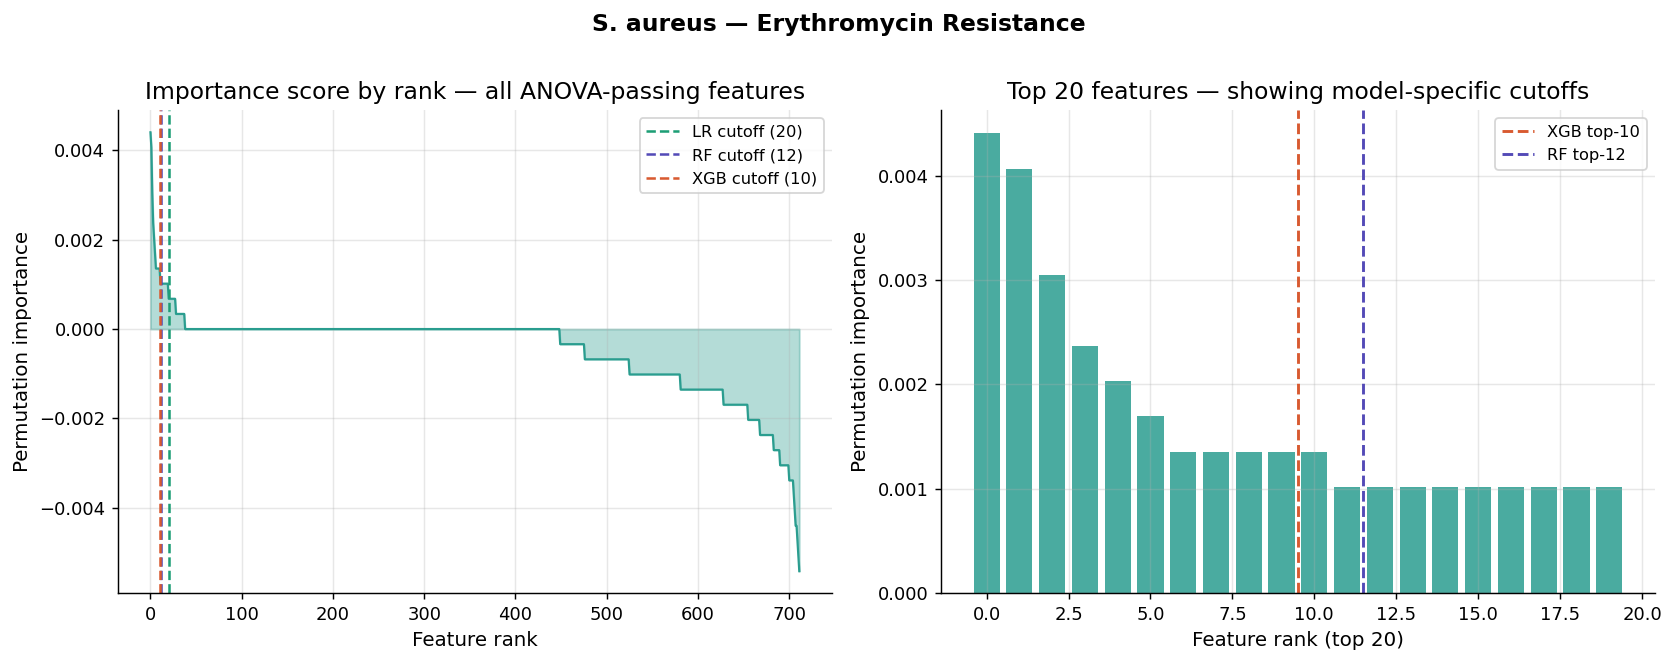

Saved: feature_importance_distribution.png


In [10]:
importance_df = pd.read_csv(os.path.join(DATA_DIR, "feature_importances.csv"))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Left — all ANOVA features
ax1.fill_between(range(len(importance_df)), importance_df["importance"], alpha=0.35, color="#2a9d8f")
ax1.plot(importance_df["importance"], color="#2a9d8f", lw=1.2)
for model, cutoff, color in [("LR", TOP_K["LR"], "#1D9E75"),
                               ("RF", TOP_K["RF"], "#534AB7"),
                               ("XGB", TOP_K["XGB"], "#D85A30")]:
    ax1.axvline(cutoff, color=color, linestyle="--", lw=1.4, label=f"{model} cutoff ({cutoff})")
ax1.set_xlabel("Feature rank")
ax1.set_ylabel("Permutation importance")
ax1.set_title("Importance score by rank — all ANOVA-passing features")
ax1.legend(fontsize=9)

# Right — top 20 zoom
top_n = 20
top_df = importance_df.head(top_n)
ax2.bar(range(len(top_df)), top_df["importance"], color="#2a9d8f", alpha=0.85)
for model, cutoff, color in [("XGB", TOP_K["XGB"], "#D85A30"),
                               ("RF", TOP_K["RF"], "#534AB7")]:
    if cutoff <= top_n:
        ax2.axvline(cutoff - 0.5, color=color, linestyle="--", lw=1.6, label=f"{model} top-{cutoff}")
ax2.set_xlabel("Feature rank (top 20)")
ax2.set_ylabel("Permutation importance")
ax2.set_title("Top 20 features — showing model-specific cutoffs")
ax2.legend(fontsize=9)

plt.suptitle("S. aureus — Erythromycin Resistance", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "feature_importance_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved: feature_importance_distribution.png")

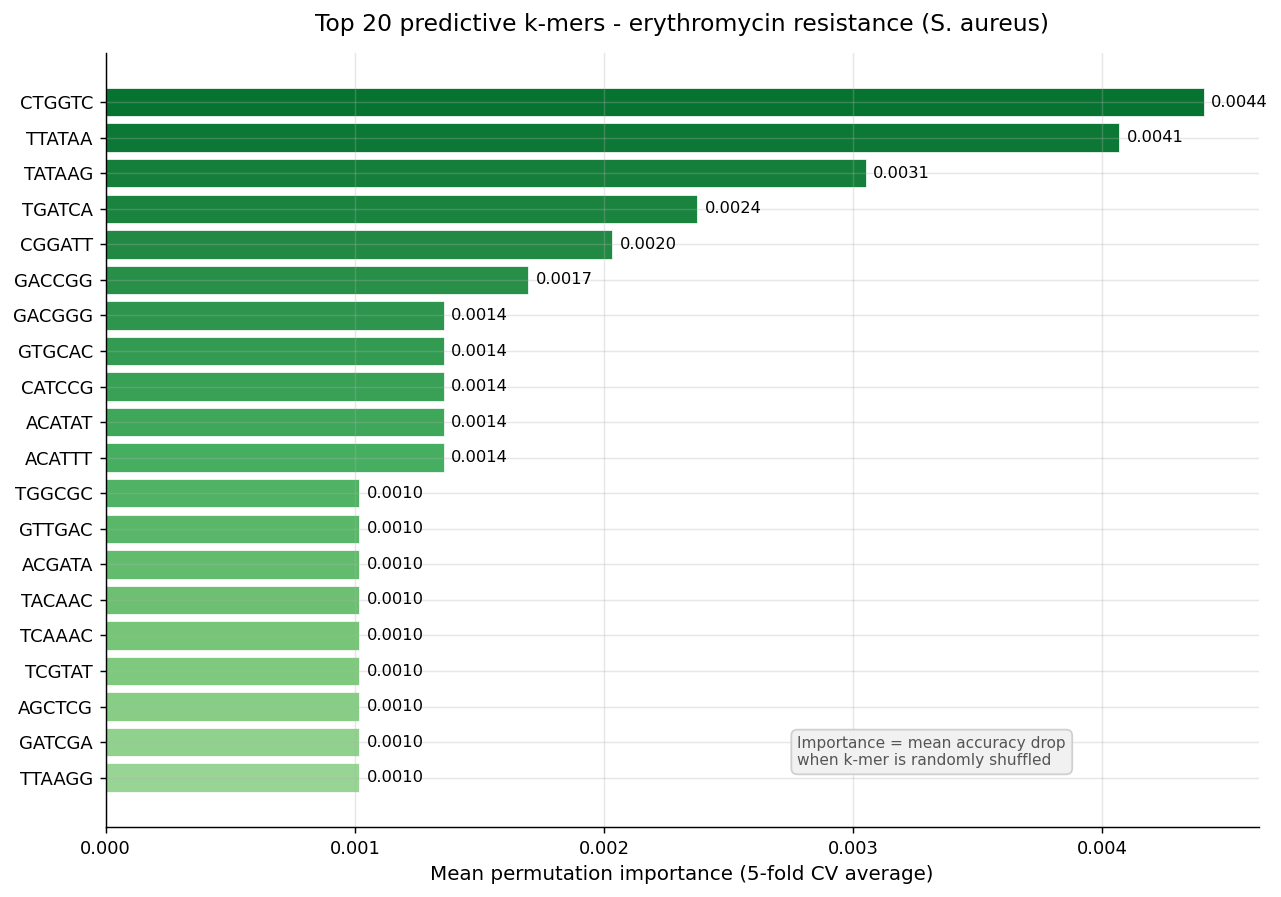

Saved: top20_features.png


In [12]:
top20 = importance_df.head(20).copy()
top20 = top20.sort_values("importance")

fig, ax = plt.subplots(figsize=(10, 7))
colors_bar = plt.cm.Greens(np.linspace(0.40, 0.85, len(top20)))
bars = ax.barh(top20["feature"], top20["importance"], color=colors_bar,
               edgecolor="white", linewidth=0.4)

for bar, val in zip(bars, top20["importance"]):
    ax.text(val + 0.00003, bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}", va="center", fontsize=9)

ax.set_xlabel("Mean permutation importance (5-fold CV average)", fontsize=11)
ax.set_title("Top 20 predictive k-mers - erythromycin resistance (S. aureus)", fontsize=13, pad=12)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.text(0.60, 0.08, "Importance = mean accuracy drop\nwhen k-mer is randomly shuffled",
        transform=ax.transAxes, fontsize=8.5, color="#555555",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="#f0f0f0", edgecolor="#cccccc", alpha=0.9))
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "top20_features.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved: top20_features.png")

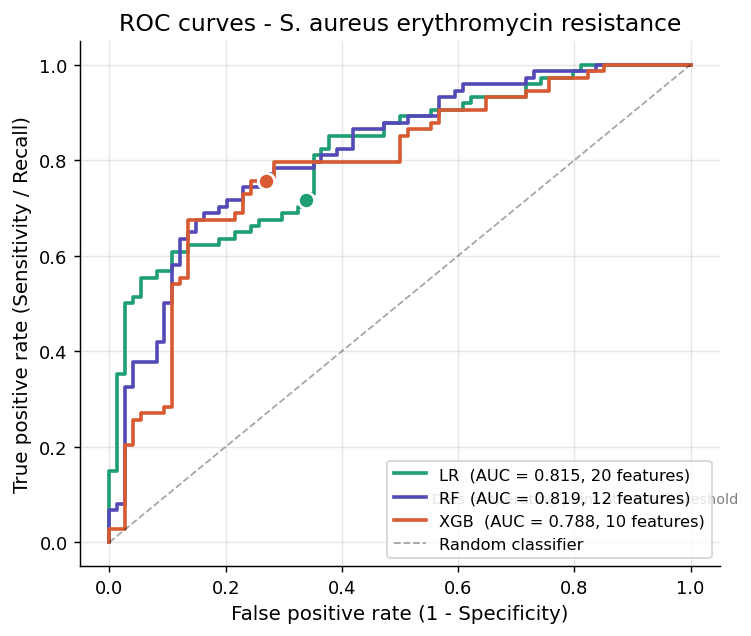

Saved: roc_curves.png


In [14]:
fig, ax = plt.subplots(figsize=(6, 5))

for k, m in MODELS.items():
    fpr, tpr, _ = roc_curve(m["yte"], m["te_prob"])
    auc = roc_auc_score(m["yte"], m["te_prob"])
    ax.plot(fpr, tpr, color=COLORS[k], lw=2,
            label=f"{k}  (AUC = {auc:.3f}, {m['feats']} features)")
    t = m["threshold"]
    te_pred_pts = (m["te_prob"] >= t).astype(int)
    op_tpr = recall_score(m["yte"], te_pred_pts)
    op_fpr = 1 - recall_score(1 - m["yte"], 1 - te_pred_pts)
    ax.scatter(op_fpr, op_tpr, color=COLORS[k], s=80, zorder=5,
               edgecolors="white", linewidths=1.5)

ax.plot([0,1],[0,1], "k--", alpha=0.35, lw=1, label="Random classifier")
ax.set_xlabel("False positive rate (1 - Specificity)")
ax.set_ylabel("True positive rate (Sensitivity / Recall)")
ax.set_title("ROC curves - S. aureus erythromycin resistance")
ax.legend(fontsize=9, loc="lower right")
ax.text(0.55, 0.12, "Dots = operating point at tuned threshold",
        fontsize=8, color="gray", transform=ax.transAxes)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "roc_curves.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved: roc_curves.png")

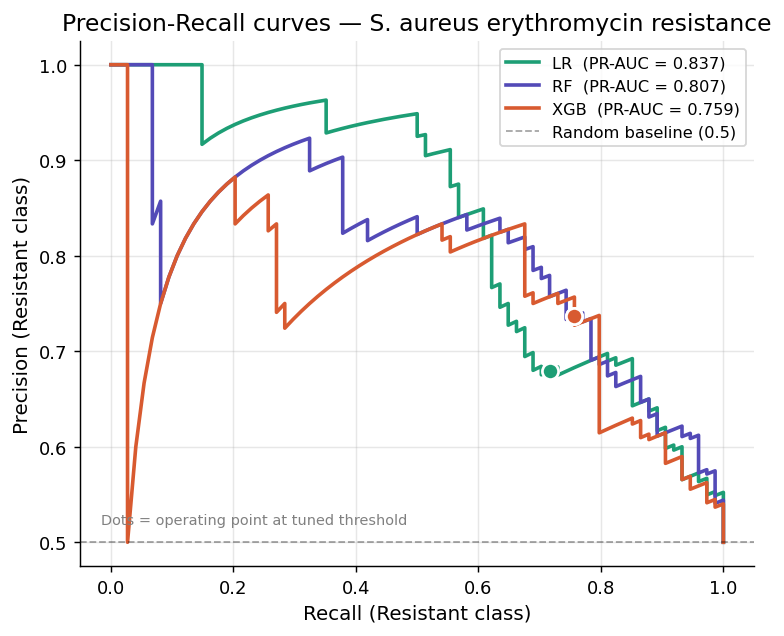

Saved: pr_curves.png


In [15]:
fig, ax = plt.subplots(figsize=(6, 5))

for k, m in MODELS.items():
    prec, rec, _ = precision_recall_curve(m["yte"], m["te_prob"])
    ap = average_precision_score(m["yte"], m["te_prob"])
    ax.plot(rec, prec, color=COLORS[k], lw=2, label=f"{k}  (PR-AUC = {ap:.3f})")
    op_rec  = recall_score(m["yte"], m["te_pred"])
    op_prec = precision_score(m["yte"], m["te_pred"])
    ax.scatter(op_rec, op_prec, color=COLORS[k], s=80, zorder=5,
               edgecolors="white", linewidths=1.5)

ax.axhline(0.5, color="k", linestyle="--", alpha=0.35, lw=1, label="Random baseline (0.5)")
ax.set_xlabel("Recall (Resistant class)")
ax.set_ylabel("Precision (Resistant class)")
ax.set_title("Precision-Recall curves — S. aureus erythromycin resistance")
ax.legend(fontsize=9)
ax.text(0.03, 0.08, "Dots = operating point at tuned threshold",
        fontsize=8, color="gray", transform=ax.transAxes)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "pr_curves.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved: pr_curves.png")

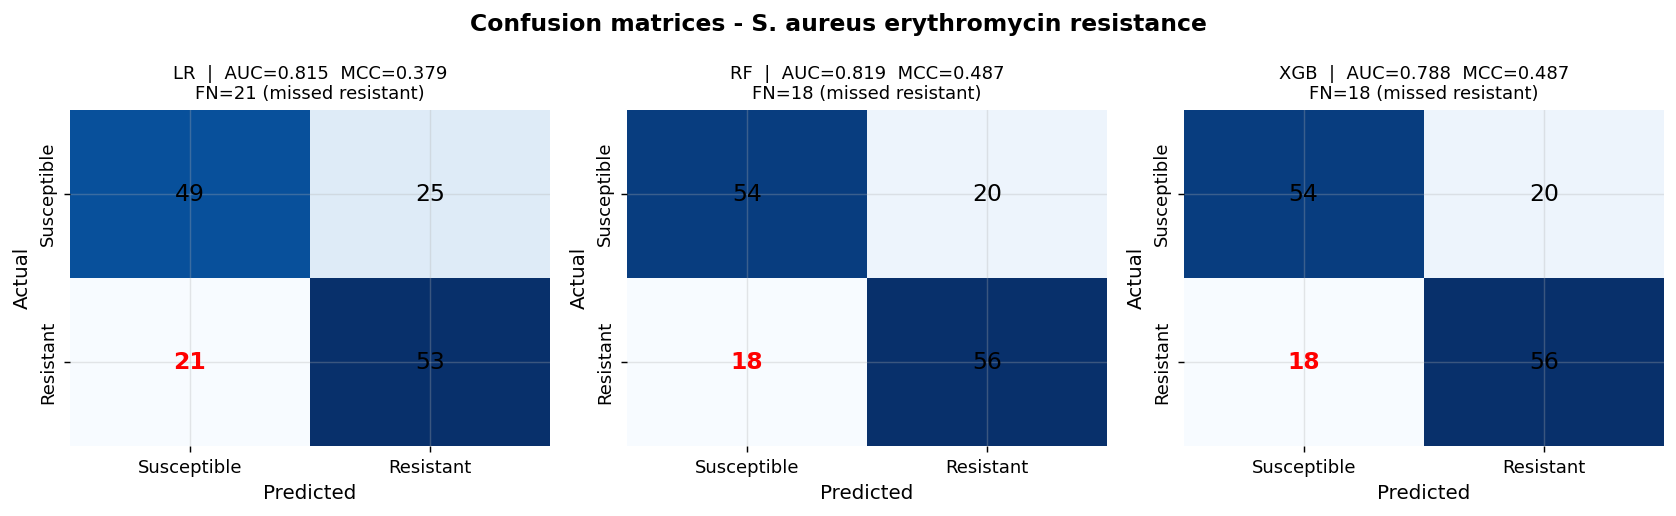

Saved: confusion_matrices.png


In [20]:
CLASS_NAMES = ["Susceptible", "Resistant"]
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, (k, m) in zip(axes, MODELS.items()):
    cm = confusion_matrix(m["yte"], m["te_pred"])
    auc = roc_auc_score(m["yte"], m["te_prob"])
    mcc = matthews_corrcoef(m["yte"], m["te_pred"])
    fn  = cm[1, 0]

    # Draw heatmap without annotations
    sns.heatmap(cm, annot=False, cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=ax, cbar=False)

    # Annotate each cell — FN in red, rest in black
    for row in range(2):
        for col in range(2):
            is_fn = (row == 1 and col == 0)
            ax.text(col + 0.5, row + 0.5, str(cm[row, col]),
                    ha="center", va="center", fontsize=13,
                    color="red" if is_fn else "black",
                    fontweight="bold" if is_fn else "normal")

    title = f"{k}  |  AUC={auc:.3f}  MCC={mcc:.3f}\nFN={fn} (missed resistant)"
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Confusion matrices - S. aureus erythromycin resistance", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "confusion_matrices.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved: confusion_matrices.png")

In [22]:
print("All S. aureus plots generated!")
print(f"All files saved to: {DATA_DIR}")
print("Files created:")
for f in ["feature_importance_distribution.png", "top20_features.png",
          "roc_curves.png", "pr_curves.png", "confusion_matrices.png",
          "final_results.csv"]:
    path = os.path.join(DATA_DIR, f)
    exists = "V" if os.path.exists(path) else "X MISSING"
    print(f"  {exists}  {f}")

All S. aureus plots generated!
All files saved to: C:\AMR_Prediction_Project\Data\results_saureus
Files created:
  V  feature_importance_distribution.png
  V  top20_features.png
  V  roc_curves.png
  V  pr_curves.png
  V  confusion_matrices.png
  V  final_results.csv
